In [3]:
! pip install -r ./DeblurGANv2/requirements.txt 

     ---------------------------------------- 0.0/29.7 MB ? eta -:--:--
     - -------------------------------------- 1.0/29.7 MB 8.5 MB/s eta 0:00:04
     ----- ---------------------------------- 3.9/29.7 MB 12.4 MB/s eta 0:00:03
     -------- ------------------------------- 6.6/29.7 MB 11.8 MB/s eta 0:00:02
     ------------- -------------------------- 9.7/29.7 MB 12.9 MB/s eta 0:00:02
     ----------------- --------------------- 13.4/29.7 MB 13.8 MB/s eta 0:00:02
     ---------------------- ---------------- 17.3/29.7 MB 14.5 MB/s eta 0:00:01
     -------------------------- ------------ 20.4/29.7 MB 14.9 MB/s eta 0:00:01
     -------------------------------- ------ 24.6/29.7 MB 15.3 MB/s eta 0:00:01
     ------------------------------------- - 28.3/29.7 MB 15.6 MB/s eta 0:00:01
     --------------------------------------- 29.7/29.7 MB 15.2 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to b


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Exception:
Traceback (most recent call last):
  File "C:\Python\Lib\site-packages\pip\_internal\cli\base_command.py", line 106, in _run_wrapper
    status = _inner_run()
             ^^^^^^^^^^^^
  File "C:\Python\Lib\site-packages\pip\_internal\cli\base_command.py", line 97, in _inner_run
    return self.run(options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python\Lib\site-packages\pip\_internal\cli\req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python\Lib\site-packages\pip\_internal\commands\install.py", line 386, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "C:\Python\Lib\site-packages\pip\_internal\resolution\resolvelib\resolver.py", line 95, in resolve
    result = self._result = resolver.resolve(
                   

In [3]:
import os
 
# Function to Get the current
# working directory
def current_path():
    print("Current working directory before")
    print(os.getcwd())
    print()
 
 
# Driver's code
# Printing CWD before
current_path()
 
# Changing the CWD
os.chdir('./DeblurGANv2')
 
# Printing CWD after
current_path()

Current working directory before
d:\Image_Deblurring\Code\DeblurGANv2

Current working directory before
d:\Image_Deblurring\Code\DeblurGANv2\DeblurGANv2



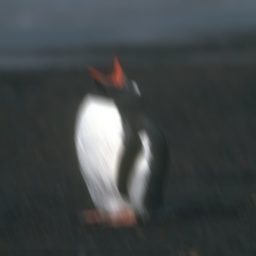

In [4]:
from IPython.display import Image
Image(filename='penguin_blur.png') 

In [2]:
! python predict.py blurry-image.jpg

In [9]:
! python predict1.py tree_blur.png


  0%|          | 0/1 [00:00<?, ?it/s][ WARN:0@5.688] global loadsave.cpp:268 cv::findDecoder imread_(''): can't open/read file: check file path/integrity
d:\Image_Deblurring\Code\DeblurGANv2\DeblurGANv2\models\fpn_inception.py:164: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  map3 = self.td1(lateral3 + nn.functional.upsample(map4, scale_factor=2, mode="nearest"))
d:\Image_Deblurring\Code\DeblurGANv2\DeblurGANv2\models\fpn_inception.py:165: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  map2 = self.td2(F.pad(lateral2, pad, "reflect") + nn.functional.upsample(map3, scale_factor=2, mode="nearest"))
d:\Image_Deblurring\Code\DeblurGANv2\DeblurGANv2\models\fpn_inception.py:166: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  map1 = self.td3(lateral1 + nn.functional.upsample(map2, scale_factor=2, mode="nearest"))
d:\Image_Deblurring\Code\DeblurGA

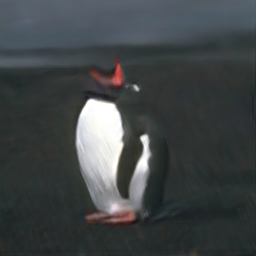

In [9]:
from IPython.display import Image
Image(filename='submit/penguin_blur.png') 

In [10]:
import os
import torch
import lpips
import numpy as np
from skimage.io import imread
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import structural_similarity as compare_ssim
from tqdm import tqdm

# Setup LPIPS model
lpips_model = lpips.LPIPS(net='alex').eval()  # Options: 'alex', 'vgg', 'squeeze'

# Set paths
deblurred_dir = 'DeblurGANv2'     # Folder of output images
ground_truth_dir = 'DeblurGANv2/submit'  # Folder of sharp images
#image_filenames = sorted(os.listdir(deblurred_dir))
image_filenames = 'test01.png'
# Metrics storage
psnr_scores = []
ssim_scores = []
lpips_scores = []

# Iterate and compute metrics
#for filename in tqdm(image_filenames, desc="Evaluating images"):
for filename in tqdm(image_filenames, desc="Evaluating images"):
    filename = 'test01.png'
    if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue
    
    print(filename)
    # Load images
    #deblurred = imread(os.path.join(deblurred_dir, filename)) / 255.0
    deblurred = imread('submit/penguin_blur.png')/ 255.0
    #groundtruth = imread(os.path.join(ground_truth_dir, filename)) / 255.0
    groundtruth = imread('penguin_sharp.png')/ 255.0
    # Resize/check shape if needed
    if deblurred.shape != groundtruth.shape:
        print(f"Skipping {filename}: size mismatch.")
        continue

    # PSNR
    psnr = compare_psnr(groundtruth, deblurred, data_range=1.0)
    psnr_scores.append(psnr)

    # SSIM
    ssim = compare_ssim(groundtruth, deblurred, channel_axis=-1, data_range=1.0)
    ssim_scores.append(ssim)

    # LPIPS
    tensor_d = torch.tensor(deblurred).permute(2, 0, 1).unsqueeze(0).float()
    tensor_g = torch.tensor(groundtruth).permute(2, 0, 1).unsqueeze(0).float()
    lpips_score = lpips_model(tensor_d, tensor_g).item()
    lpips_scores.append(lpips_score)

# Results
print("\n--- Average Metrics ---")
print(f"PSNR:  {np.mean(psnr_scores):.2f} dB")
print(f"SSIM:  {np.mean(ssim_scores):.4f}")
print(f"LPIPS: {np.mean(lpips_scores):.4f}")


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Python\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Python\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Python\Lib\site-packages\lpips\weights\v0.1\alex.pth


Evaluating images:  10%|█         | 1/10 [00:00<00:01,  6.79it/s]

test01.png
test01.png


Evaluating images:  70%|███████   | 7/10 [00:00<00:00, 20.15it/s]

test01.png
test01.png
test01.png
test01.png
test01.png


Evaluating images: 100%|██████████| 10/10 [00:00<00:00, 19.68it/s]

test01.png
test01.png
test01.png

--- Average Metrics ---
PSNR:  32.25 dB
SSIM:  0.8766
LPIPS: 0.1529
